# Climate Change

This notebook looks at two long-running climate records: the concentration of carbon dioxide in the atmosphere, and the extent of sea ice in the Arctic. Together they show the cause and one of the clearest effects of a warming planet. Along the way, each dataset is checked against its source documentation, because a plot is only as trustworthy as the numbers behind it.

---

# Atmospheric CO2 at Mauna Loa

Mauna Loa monthly CO2: <https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_mm_mlo.txt>

Since March 1958, CO2 has been measured continuously near the summit of Mauna Loa in Hawaii, far from local pollution sources. This record, now maintained by NOAA's Global Monitoring Laboratory, is the longest direct measurement of atmospheric CO2 in existence. The data used here are 822 monthly averages. from March 1958 through August 2026, reported in parts per million (ppm). 

Two details from the file's documentation shape how the record should read. Some months have missing statistics, which the file marks with negative placeholder values rather than blanks. And after the 2022 Mauna Loa eruption, measurements were temporarily taken at nearby Maunakea, a change that is invisible in the numbers themselves. 

In [1]:
import pandas as pd
import ibis
from plotnine import *

In [2]:
import pandas as pd

url = "https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_mm_mlo.txt"

cols = [
    "year", "month", "decimal_date", "average",
    "deseasonalized", "ndays", "stdev", "uncertainty",
]

df = pd.read_csv(
    url,
    sep=r"\s+",
    comment="#",
    header=None,
    names=cols,
)


In [3]:
missing_code_cols = ["ndays", "stdev", "uncertainty"]

df[missing_code_cols] = df[missing_code_cols].mask(
    df[missing_code_cols] < 0, pd.NA,
)


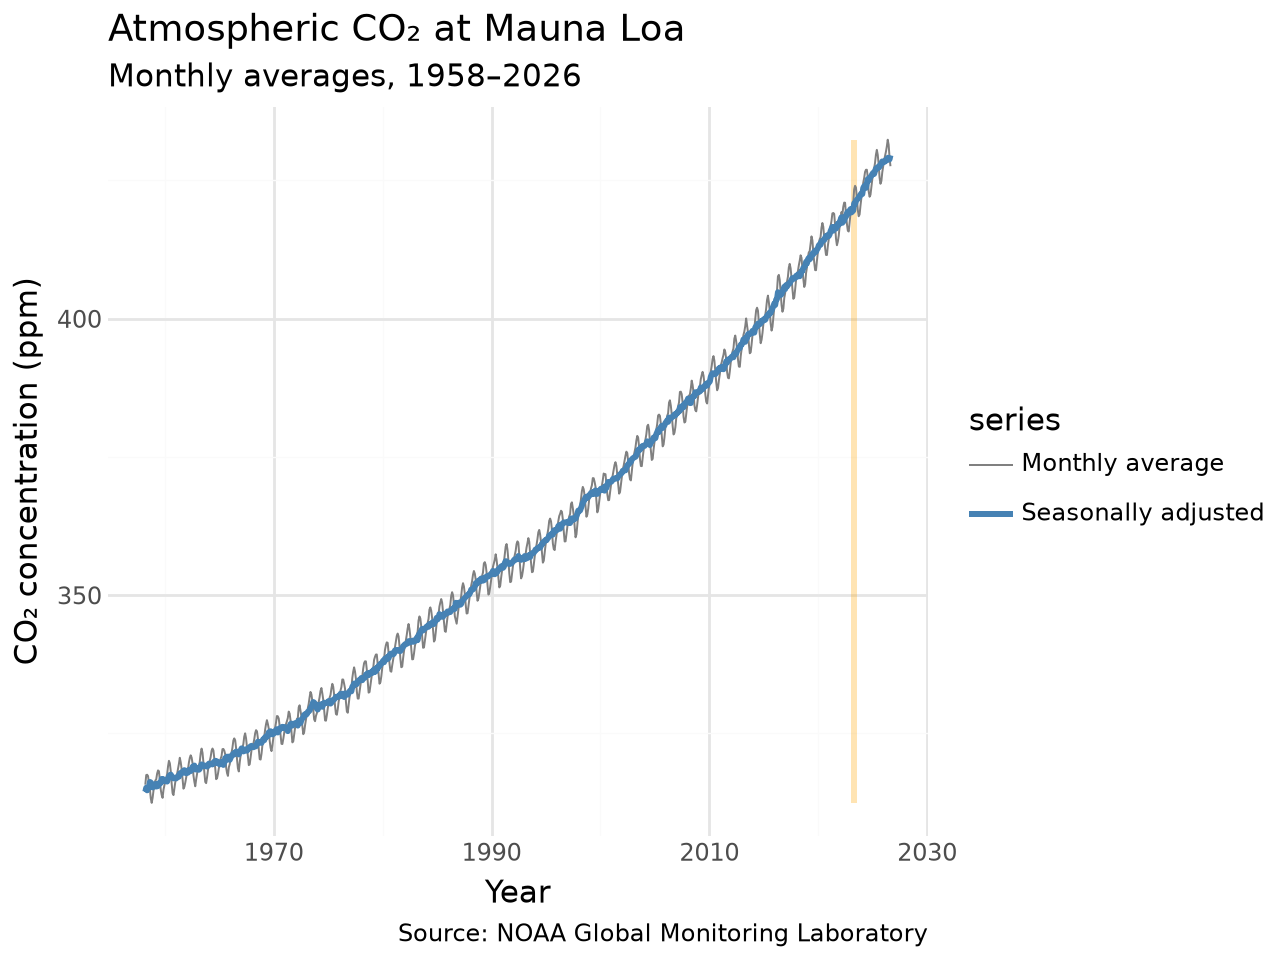

In [4]:
co2_long = df.melt(
    id_vars="decimal_date",
    value_vars=["average", "deseasonalized"],
    var_name="series",
    value_name="co2",
).replace({"series": {"average": "Monthly average", "deseasonalized": "Seasonally adjusted"}})

maunakea_start = df.loc[df["year"] == 2022, "decimal_date"].max()
maunakea_end = df.loc[(df["year"] == 2023) & (df["month"] == 7), "decimal_date"].iloc[0]

(
    ggplot(co2_long, aes(x="decimal_date", y="co2", color="series", size="series"))
    + annotate("rect", xmin=maunakea_start, xmax=maunakea_end,
               ymin=df["average"].min(), ymax=df["average"].max(),
               fill="orange", alpha=0.3)
    + geom_line()
    + scale_color_manual(name="", values={"Monthly average": "grey", "Seasonally adjusted": "steelblue"})
    + scale_size_manual(name="", values={"Monthly average": 0.4, "Seasonally adjusted": 1.2})
    + theme_minimal()
    + labs(
        title="Atmospheric CO₂ at Mauna Loa",
        subtitle=f"Monthly averages, {df['year'].min()}–{df['year'].max()}",
        x="Year",
        y="CO₂ concentration (ppm)",
        caption="Source: NOAA Global Monitoring Laboratory",
    )
)

### From the Source



Comparing the header block in the columns list, the column names that are misstated for what they hold include "smooth" instead of "deseasonalized", "std_days" instead of "ndays", and there is "uncertainty" instead of "unc. of mon mean". The mismatched name for std_days would change a published figure if anyone noticed since treating the number of days as a standard deviation value could result in statistical assumptions or error bars that are inaccurate. The deseasonalized column could influence interpretation of a figure if this column specifically was being analyzed. The uncertainty discrepancies would primarily influence interpretation, not a published figure. 

### Code Discrepancy



The raw file uses negative values to indicate measurements or statistics that were not available. A naive mean() would be lowered down by these negative values, a min() would result in a negative value that wouldn't be interpretable in the context of this dataset, and for error bars, they could also produce incorrect or misleading error bars. To mitigate this issue, I changed the negative values to NA so that they would not be considered in numerical analysis.

In [5]:
filtered = df[
    ((df["year"] == 2022) & (df["month"] >= 11)) |
    ((df["year"] == 2023) & (df["month"] <= 8))
]

filtered[["year", "month", "average"]]

,year,month,average
776,2022,11,417.47
777,2022,12,418.99
778,2023,1,419.48
779,2023,2,420.31
780,2023,3,420.99
781,2023,4,423.35
782,2023,5,424.00
783,2023,6,423.68
784,2023,7,421.83
785,2023,8,419.68


### What changed in 2022?


The header block notes that the measurement location temporarily changed from Mauna Loa to Maunakea in 2022-2023. The data still looks like a continuous series (for example, 417.47 ppm in November 2022 and 418.99 ppm in December 2022), so this change would not be apparent from the numeric columns alone. A model using only the numbers would not be able to tell that the measurement location had changed. 

In [6]:
csv_url = "https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_mm_mlo.csv"

csv_df = pd.read_csv(csv_url, comment="#")

csv_df.head()

,year,month,decimal date,average,deseasonalized,ndays,sdev,unc
0,1958,3,1958.2027,315.71,314.44,-1,-9.99,-0.99
1,1958,4,1958.2877,317.45,315.16,-1,-9.99,-0.99
2,1958,5,1958.3699,317.51,314.69,-1,-9.99,-0.99
3,1958,6,1958.4548,317.27,315.15,-1,-9.99,-0.99
4,1958,7,1958.5370,315.87,315.20,-1,-9.99,-0.99


### How does the CSV compare?


I loaded NOAA's CSV version of the same CO2 records. The CSV solves the formatting and parsing issues that are present in a text file since the data is already organized into columns. However, it does not solve data-specific issues such as negative values representing missing values or the missing location identification in a column.

In [7]:
import ibis

con = ibis.duckdb.connect()
url = "https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_mm_mlo.txt"

t = con.read_csv(url)

t.head()

r0 := DatabaseTable: ibis_read_csv_sl2ck5dvpnenldbjrrgkygzs24
  # -------------------------------------------------------------------- string

Limit[r0, n=5]

### Trying with Ibis


Ibis did not correctly parse the original .txt file as a data table. It treated the first metadata line (#--------------) as the column name and the header as text data. This likely happened because the file contains metadata before the measurements that are separated by whitespace. As we can see here, "always use Ibis" is not a reliable rule since the file format determines how the data needs to be parsed.

### How do we know these numbers are right?

1. Extent: 822 monthly rows from March 1958 through August 2026.
2. Missing data: Negative values in ndays, stdev, and uncertainty indicate unavailable values, and these values were changed to NA.
3. Units: CO2 concentration is reported in ppm.
4. Completeness: Full monthly record available from March 1958 through August 2026.
5. Cross-check: The first record, March 1958 at 315.71 ppm which matches the NOAA source.

---

# Arctic Sea Ice Extent

National Snow and Ice Data Center, sea ice index G02135:

- Documentation: <https://nsidc.org/data/G02135>
- Data directory: <https://noaadata.apps.nsidc.org/NOAA/G02135/north/monthly/data/>

Satellites have tracked Arctic sea ice since November 1978. The National Snow and Ice Data Center's Sea Ice Index reports sea ice extent (G02135): the total area of ocean where at least 15% of the surface is covered by ice, in millions of square kilometers. The monthly record is split across 12 files, one for each calendar month, so all 12 have to be combined to build the full series from November 1978 to August 2026. 

Arctic ice grows each winter and melts each summer, reaching its lowerst point in September. Because the September extent reflects how much ice survives the melt season, it is the standard measure of long-term Arctic sea ice loss, and it is the focus of this section of analysis. 
```

### What it Loaded




The model found 12 CSV files from the NSIDC directory, and the files it used existed in the directory. It loaded 574 rows that covered November 1978 through August 2026. The plot title says how it shows the trend, but 2026 is incomplete, ending in August. The filenames come from inspecting the directory listing with urlopen and a regular expression.

### Building the complete record



In [8]:
base_url = "https://noaadata.apps.nsidc.org/NOAA/G02135/north/monthly/data/"

csv_files = [f"N_{m:02d}_extent_v4.0.csv" for m in range(1, 13)]
urls = [base_url + f for f in csv_files]

urls

['https://noaadata.apps.nsidc.org/NOAA/G02135/north/monthly/data/N_01_extent_v4.0.csv',
 'https://noaadata.apps.nsidc.org/NOAA/G02135/north/monthly/data/N_02_extent_v4.0.csv',
 'https://noaadata.apps.nsidc.org/NOAA/G02135/north/monthly/data/N_03_extent_v4.0.csv',
 'https://noaadata.apps.nsidc.org/NOAA/G02135/north/monthly/data/N_04_extent_v4.0.csv',
 'https://noaadata.apps.nsidc.org/NOAA/G02135/north/monthly/data/N_05_extent_v4.0.csv',
 'https://noaadata.apps.nsidc.org/NOAA/G02135/north/monthly/data/N_06_extent_v4.0.csv',
 'https://noaadata.apps.nsidc.org/NOAA/G02135/north/monthly/data/N_07_extent_v4.0.csv',
 'https://noaadata.apps.nsidc.org/NOAA/G02135/north/monthly/data/N_08_extent_v4.0.csv',
 'https://noaadata.apps.nsidc.org/NOAA/G02135/north/monthly/data/N_09_extent_v4.0.csv',
 'https://noaadata.apps.nsidc.org/NOAA/G02135/north/monthly/data/N_10_extent_v4.0.csv',
 'https://noaadata.apps.nsidc.org/NOAA/G02135/north/monthly/data/N_11_extent_v4.0.csv',
 'https://noaadata.apps.nsidc.or

In [9]:
frames = []
for url in urls:
    df = pd.read_csv(url, skipinitialspace=True)
    df.columns = df.columns.str.strip()
    frames.append(df)

ice = pd.concat(frames, ignore_index=True)
ice["date"] = pd.to_datetime({"year": ice["year"], "month": ice["mo"], "day": 1})
ice = ice.sort_values("date").reset_index(drop=True)


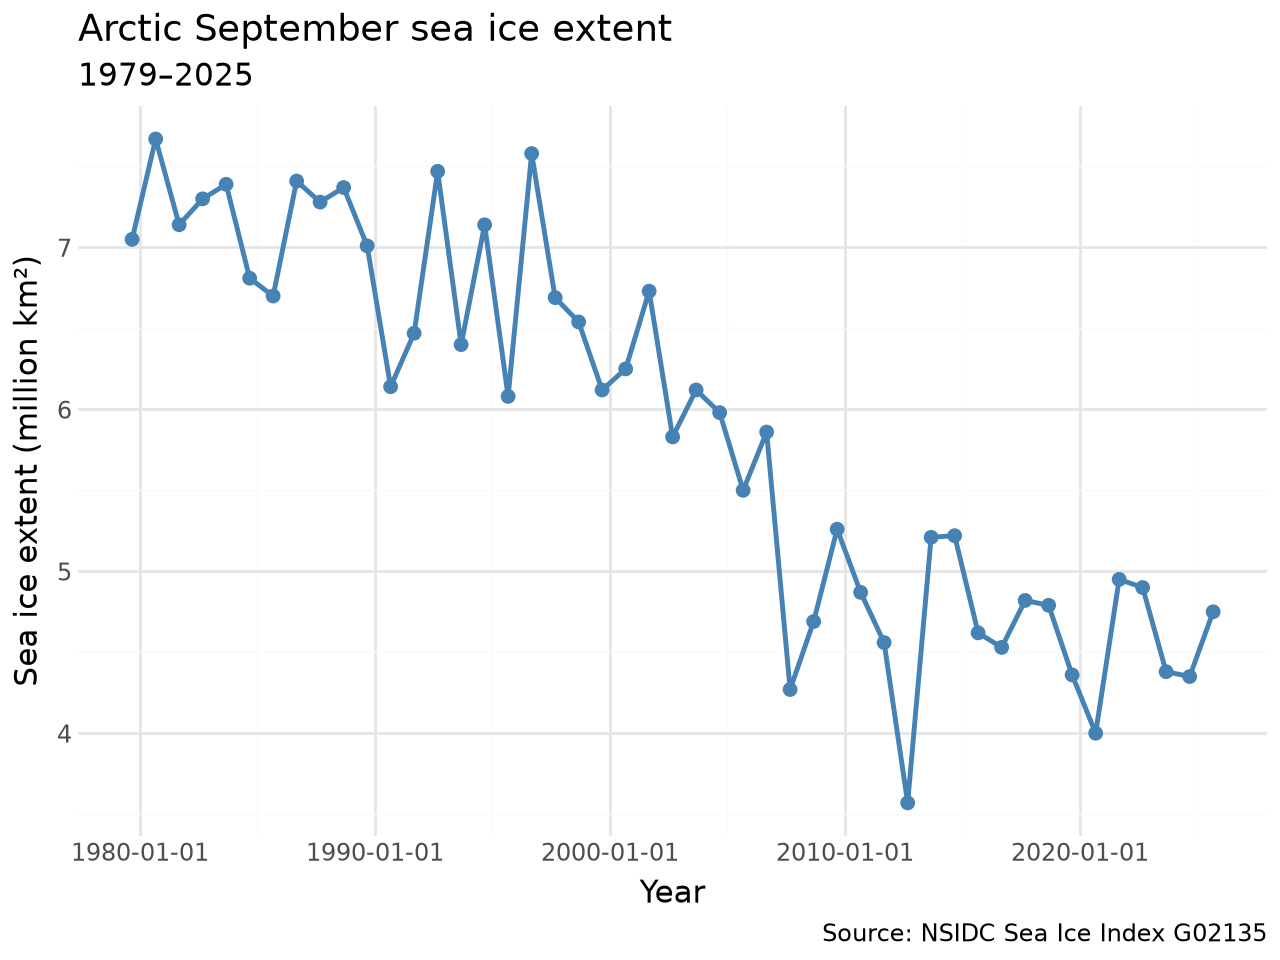

In [10]:
sept = ice[ice["mo"] == 9]

(
    ggplot(sept, aes(x="date", y="extent"))
    + geom_line(color="steelblue", size=1)
    + geom_point(color="steelblue", size=2)
    + theme_minimal()
    + labs(
        title="Arctic September sea ice extent",
        subtitle=f"{sept['year'].min()}–{sept['year'].max()}",
        x="Year",
        y="Sea ice extent (million km²)",
        caption="Source: NSIDC Sea Ice Index G02135",
    )
)



I reported the September minimum because the question is about Arctic sea ice loss over time. September represents the annual end of summer minimum making it more directly relevant to measuring long-term sea ice loss than an annual mean, which combines winter and summer conditions.

### How do we know these numbers are right?

1. Extent: 574 monthly rows, from November 1978 to August 2026
2. Missing data: No missing values were identified in the loaded extent data
3. Units: Sea ice extent is measured in million km^2, as stated in the NSIDC dataset documentation
4. Completeness: The dataset contains the full available monthly record, although 2026 is incomplete and only includes data through August.
5. Cross-check: A September extent value was checked against the NSIDC Arctic sea ice September minimum record and matched.

---

# Reflection



1. The model produced several cases of code that ran but needed to be corrected.

(a) For the NOAA CO2 .txt file, Ibis ran successfully but incorrectly interpreted the metadata as the table, treating #---------- as the column name and the header text as data.

(b) In the NOAA CO2 analysis, the model initially treated all negative values as missing. This was too broad because negative values in different columns have different meanings, so I changed the approach to handle the missing-data codes more carefully.

(c) For the NOAA CO2 location change, the model could not determine from the numeric columns that measurements temporarily moved from Mauna Loa to Maunakea. I had to use the source documentation to identiy this limitation. 

(d) For the Arctic sea ice data, the model's initial output included data through August 2026, so it was important to recognize that 2026 was an incomplete year rather than treating it as a complete annual record.

(e) The model had initially plotted the fully monthly Arctic sea ice record, but the scientific question required deciding whether to report the annual mean or September minimum. The model could not make that choice from the data-loading step alone; the source documentation established that September minimum is the standard index for Arctic sea ice loss. 

2. The issue I faced with parsing Ibis could be seen directly from the output because the rows clearly had metadata in them. The overly broad missing-data treatment required checking the file's documentation. The Mauna Loa/Maunakea location change also required referencing the documentation. The incomplete 2026 Arctic record could be detected from the data range and final rows. The September vs. annual mean issue required understanding the scientific purpose of the dataset.

3. The model generated and executed most of the code, but I played a role in checking whether the outputs matched the source, read the documentation, identified data-quality issues, and made the scientific decision about which Arctic sea ice measure to report. 

4. For the Arctic dataset, having the model inspect the directory before loading the files helped it discover the 12 available monthly files rather than assuming a filename. For simpler tasks, reviewing the plan added some slow points without really changing the approach itself. 

5. The right tool depended on the file format, dataset size, and task at hand. Streaming was convenient when data was online and could be loaded directly while local data could be easier to inspect and reuse. The model could suggest a tool, but ultimately I had to make the final decision based on the source and the analysis needed.